In [3]:
import warnings
warnings.filterwarnings('ignore')

from mom6_tools.m6toolbox import cime_xmlquery
import yaml, os
import numpy as np
import xarray as xr
import matplotlib
from mom6_tools import m6toolbox

# Configure mom6-tools

In [5]:
# Read in the yaml file
diag_config_yml_path = "no-GM.yaml"
diag_config_yml = yaml.load(open(diag_config_yml_path,'r'), Loader=yaml.Loader)

In [6]:
caseroot = diag_config_yml['Case']['CASEROOT']
casename = cime_xmlquery(caseroot, 'CASE')
DOUT_S = cime_xmlquery(caseroot, 'DOUT_S')
if DOUT_S:
  OUTDIR = cime_xmlquery(caseroot, 'DOUT_S_ROOT')+'/ocn/hist/'
else:
  OUTDIR = cime_xmlquery(caseroot, 'RUNDIR')

In [7]:
print('Output directory is:', OUTDIR)

Output directory is: /glade/derecho/scratch/pavelp/archive/no-GM/ocn/hist/


In [8]:
print('Casename is:', casename)

Casename is: no-GM


In [9]:
# create an empty class object
class args:
  pass

args.static = casename+diag_config_yml['Fnames']['static']
args.native = casename+diag_config_yml['Fnames']['native']
args.geom =   casename+diag_config_yml['Fnames']['geom']

In [15]:
# Load the grid
from mom6_tools.MOM6grid import MOM6grid

geom_file = OUTDIR+'/'+args.geom
if os.path.exists(geom_file):
  grd = MOM6grid(OUTDIR+'/'+args.static, geom_file, xrformat=True)
else:
  grd = MOM6grid(OUTDIR+'/'+args.static, xrformat=True)

MOM6 grid successfully loaded... 



In [18]:
%time ds = xr.open_mfdataset(OUTDIR+'/'+casename+'.mom6.h.sfc.000?-??.nc', \
         parallel=True, data_vars='minimal', chunks={'time': 12},\
         coords='minimal', compat='override')

CPU times: user 4.29 s, sys: 1.77 s, total: 6.06 s
Wall time: 26.2 s


In [19]:
ds

<xarray.Dataset> Size: 68GB
Dimensions:       (time: 3285, yh: 480, xh: 540, xq: 540, yq: 480, nbnd: 2)
Coordinates:
  * time          (time) object 26kB 0001-01-01 12:00:00 ... 0009-12-31 12:00:00
  * yh            (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * xh            (xh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * xq            (xq) float64 4kB -286.3 -285.7 -285.0 ... 71.67 72.33 73.0
  * yq            (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.68 87.73 87.74
  * nbnd          (nbnd) float64 16B 1.0 2.0
Data variables: (12/24)
    tos           (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    tos_min       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    tos_max       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    sos           (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    sos_min       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    sos_max       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    ...            ...
    oml_min       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    oml_max       (time, yh, xh) float32 3GB dask.array<chunksize=(12, 480, 540), meta=np.ndarray>
    average_T1    (time) object 26kB dask.array<chunksize=(12,), meta=np.ndarray>
    average_T2    (time) object 26kB dask.array<chunksize=(12,), meta=np.ndarray>
    average_DT    (time) timedelta64[ns] 26kB dask.array<chunksize=(12,), meta=np.ndarray>
    time_bounds   (time, nbnd) object 53kB dask.array<chunksize=(12, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: no-GM
    associated_files:  areacello: no-GM.mom6.h.static.nc
    grid_type:         regular
    grid_tile:         N/A

In [20]:
area = np.ma.masked_where(grd.wet == 0, np.ma.masked_invalid(grd.areacello))
dummy1 = np.ma.masked_where(grd.wet == 0, ds.tos.mean('time'))

Basemap module not found. Some regional plots may not function properly


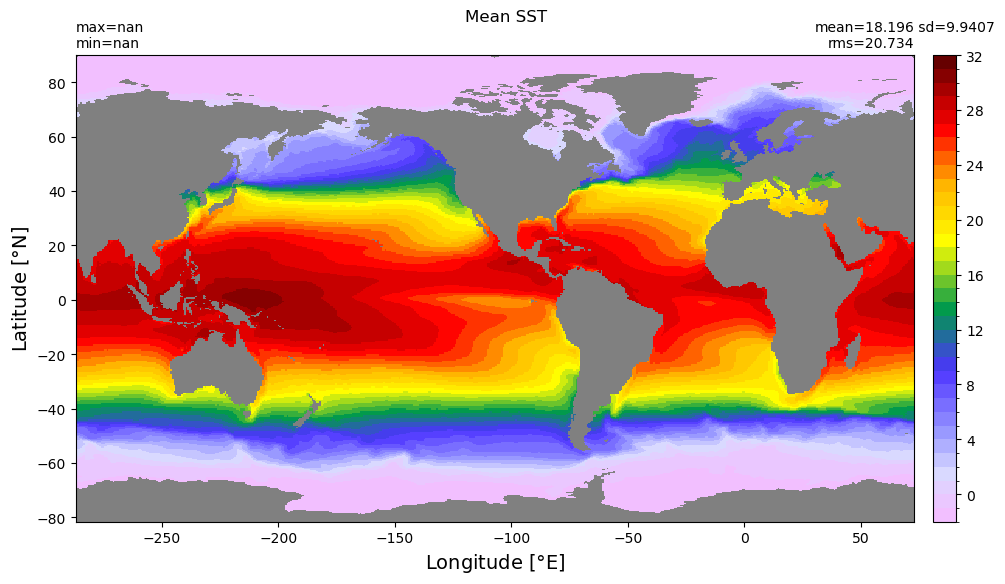

In [24]:
%matplotlib inline
# Plot mean SST
from mom6_tools.m6plot import xyplot

xyplot(dummy1, grd.geolon, grd.geolat, area , suptitle='Mean SST', clim=(-2,32))

# Time-series

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import warnings
warnings.filterwarnings("ignore")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml, os
import nc_time_axis, cftime
from datetime import datetime
import getpass
import xarray as xr
from mom6_tools.stats import extract_time_series, ocean_stats
from mom6_tools.m6toolbox import cime_xmlquery, genBasinMasks
from mom6_tools.MOM6grid import MOM6grid

In [5]:
# Make the graphs a bit prettier, and bigger
plt.style.use('ggplot')
pd.set_option('display.width', 5000)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

In [6]:
# Read in the yaml file
diag_config_yml_path = "no-GM.yaml"
diag_config_yml = yaml.load(open(diag_config_yml_path,'r'), Loader=yaml.Loader)

In [7]:
caseroot = diag_config_yml['Case']['CASEROOT']
casename = cime_xmlquery(caseroot, 'CASE')
DOUT_S = cime_xmlquery(caseroot, 'DOUT_S')
rundir = cime_xmlquery(caseroot, 'RUNDIR')

if DOUT_S:
  OUTDIR = cime_xmlquery(caseroot, 'DOUT_S_ROOT')+'/ocn/hist/'
else:
  OUTDIR = cime_xmlquery(caseroot, 'RUNDIR')

print('Rundir directory is:', rundir)
print('Casename is:', casename)

Rundir directory is: /glade/derecho/scratch/pavelp/no-GM/run
Casename is: no-GM


In [12]:
# create an empty class object
class args:
  pass

args.rundir = rundir
args.casename = casename
args.caseroot = caseroot
args.OUTDIR = OUTDIR
args.nw = 1
args.static = casename+diag_config_yml['Fnames']['static']
args.native = casename+diag_config_yml['Fnames']['native']
args.geom =   casename+diag_config_yml['Fnames']['geom']

In [13]:
# read grid info
geom_file = OUTDIR+'/'+args.geom
if os.path.exists(geom_file):
  grd = MOM6grid(OUTDIR+'/'+args.static, geom_file, xrformat=True)
else:
  grd = MOM6grid(OUTDIR+'/'+args.static, xrformat=True)

try:
  depth = grd.depth_ocean.values
except:
  depth = grd.deptho.values

try:
  area = grd.area_t.where(grd.wet > 0)
except:
  area = grd.areacello.where(grd.wet > 0)

MOM6 grid successfully loaded... 



In [27]:
# remove Nan's, otherwise genBasinMasks won't work
# Get masking for different regions
depth[np.isnan(depth)] = 0.0
basin_code = genBasinMasks(grd.geolon.values, grd.geolat.values, depth, xda=True)

#select a few basins, namely, Global, MedSea,BalticSea,HudsonBay Arctic,
# Pacific, Atlantic, Indian, Southern, LabSea and BaffinBay
basins = basin_code.isel(region=[0,4,5,6,7,8,9,10,11,12,13])

# T & S

In [16]:
variables = ['thetaoga','soga','opottempmint','somint']
ds = extract_time_series(args.native, variables, area, args)

Reading dataset...
Time elasped:  0:00:37.200709


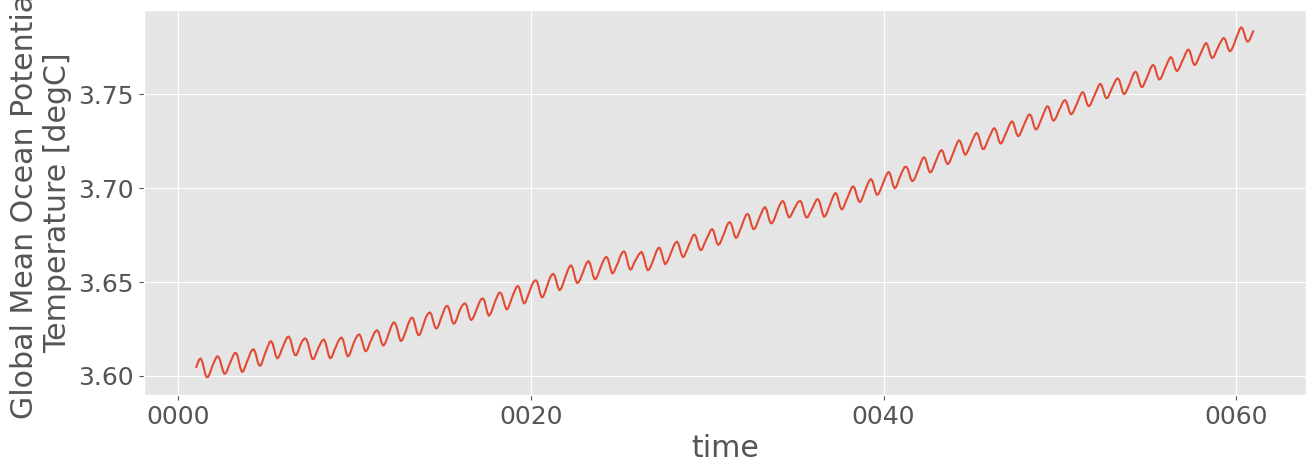

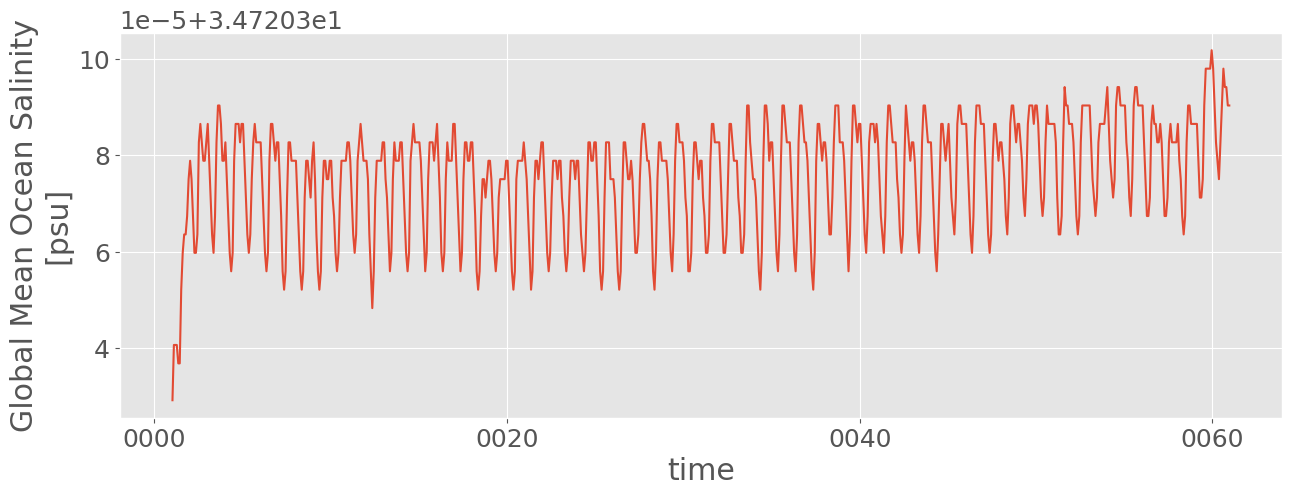

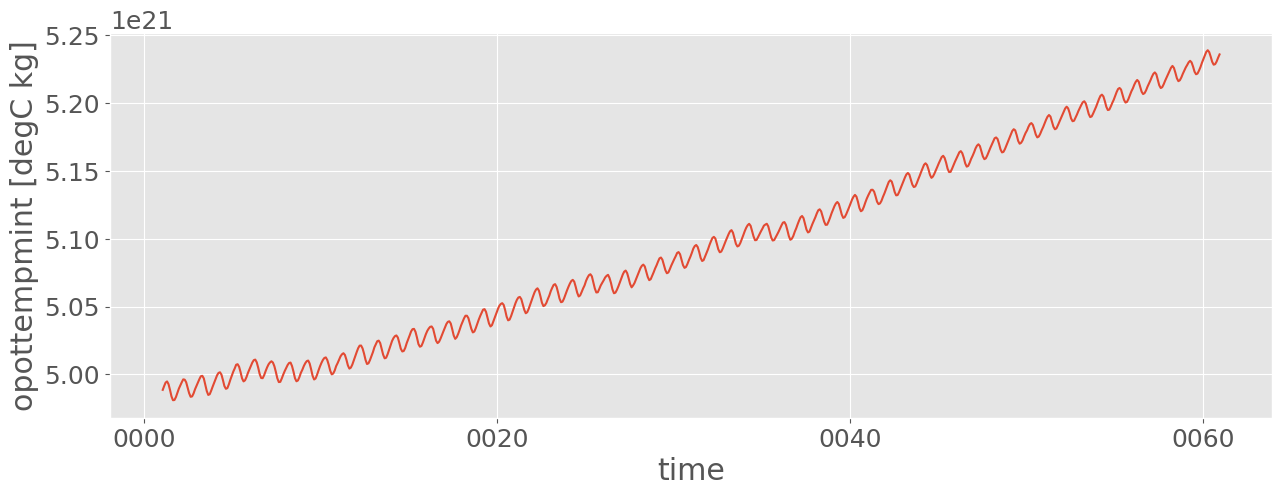

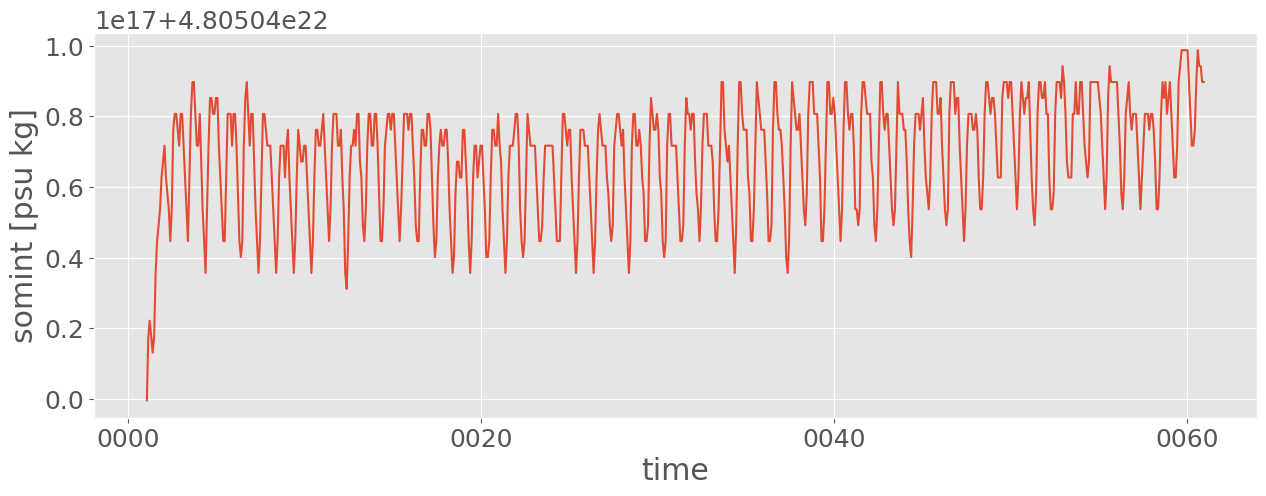

In [17]:
%matplotlib inline

for v in ds.data_vars:
    fig, ax = plt.subplots()
    ds[v].plot(ax=ax)
    ax.set_title('')

In [18]:
stats = ocean_stats(args)

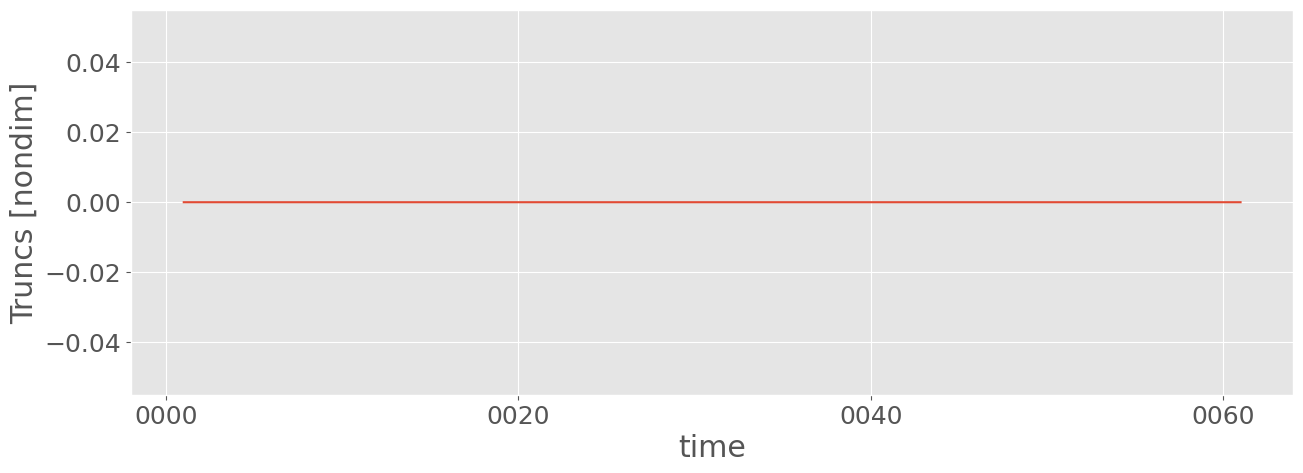

In [19]:
stats.Truncs.plot()

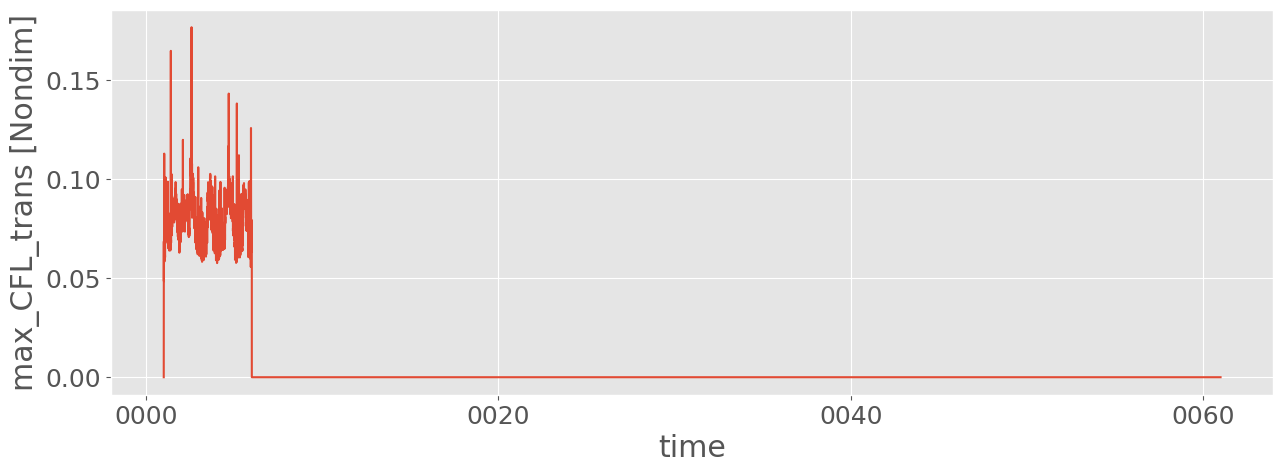

In [20]:
stats.max_CFL_trans.plot();

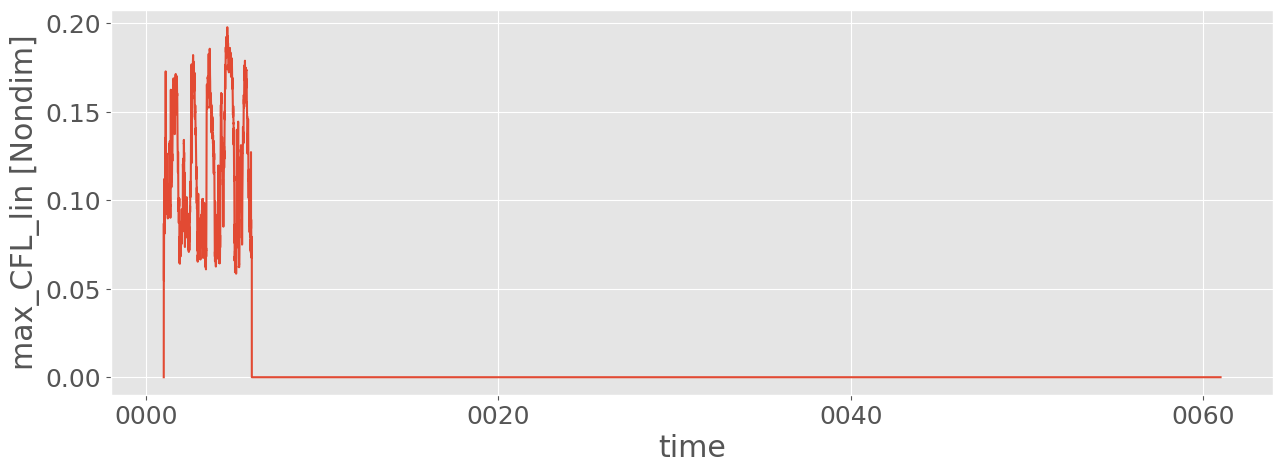

In [21]:
stats.max_CFL_lin.plot();

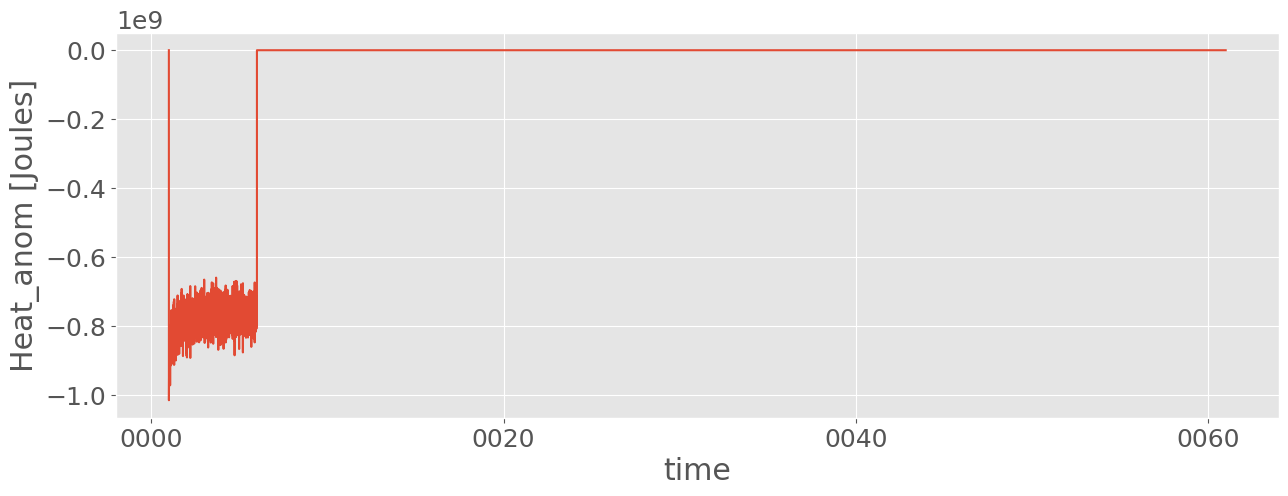

In [22]:
stats.Heat_anom.plot();

# Poleward heat transport

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import warnings
warnings.filterwarnings("ignore")
from mom6_tools.poleward_heat_transport import  *
from mom6_tools.m6toolbox import cime_xmlquery, add_global_attrs, genBasinMasks
from mom6_tools.m6toolbox import weighted_temporal_mean_vars
from datetime import datetime, date
import yaml, os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import xarray as xr

In [12]:
# Read in the yaml file
diag_config_yml_path = "no-GM.yaml"
diag_config_yml = yaml.load(open(diag_config_yml_path,'r'), Loader=yaml.Loader)

In [13]:
caseroot = diag_config_yml['Case']['CASEROOT']
casename = cime_xmlquery(caseroot, 'CASE')
DOUT_S = cime_xmlquery(caseroot, 'DOUT_S')
if DOUT_S:
  OUTDIR = cime_xmlquery(caseroot, 'DOUT_S_ROOT')+'/ocn/hist/'
else:
  OUTDIR = cime_xmlquery(caseroot, 'RUNDIR')

print('Output directory is:', OUTDIR)
print('Casename is:', casename)

Output directory is: /glade/derecho/scratch/pavelp/archive/no-GM/ocn/hist/
Casename is: no-GM


In [14]:
# create an empty class object
class args:
  pass

args.casename = casename
# set avg dates
avg = diag_config_yml['Avg']
args.start_date = avg['start_date']
args.end_date = avg['end_date']
args.native = casename+diag_config_yml['Fnames']['native']
args.static = casename+diag_config_yml['Fnames']['static']
args.geom =   casename+diag_config_yml['Fnames']['geom']
args.savefigs = False
args.nw = 1 # requesting 1 workers

In [15]:
if not os.path.isdir('ncfiles'):
    print('Creating a directory to store netcdf files (ncfiles)... \n')
    os.system('mkdir ncfiles')

In [16]:
# read grid info
geom_file = OUTDIR+'/'+args.geom
if os.path.exists(geom_file):
  grd = MOM6grid(OUTDIR+'/'+args.static, geom_file, xrformat=True)
else:
  grd = MOM6grid(OUTDIR+'/'+args.static, xrformat=True)

try:
  depth = grd.depth_ocean.values
except:
  depth = grd.deptho.values

MOM6 grid successfully loaded... 



In [17]:
# basin masks - remove Nan's, otherwise genBasinMasks won't work
depth[np.isnan(depth)] = 0.0
basin_code = genBasinMasks(grd.geolon.values, grd.geolat.values, depth, verbose=False)
basin_code_xr = genBasinMasks(grd.geolon.values, grd.geolat.values, depth, verbose=False, xda=True)

In [18]:
def preprocess(ds):
    ''' Compute montly averages and return the dataset with variables'''

    variables = ['T_ady_2d', 'T_diffy_2d', 'T_hbd_diffy_2d']
    for var in variables:
      print('Processing {}'.format(var))
      if var not in ds.variables:
        print('WARNING: ds does not have variable {}. Creating dataarray with zeros'.format(var))
        jm, im = grd.geolat.shape
        tm = len(ds.time)
        da = xr.DataArray(np.zeros((tm, jm, im)), dims=['time', 'yq','xh'], \
             coords={'yq' : grd.yq, 'xh' : grd.xh, 'time' : ds.time}).rename(var)
        ds = xr.merge([ds, da])
    return ds[variables]

In [19]:
print('\n Reading monthly native history files...')
# load data

%time ds = xr.open_mfdataset(OUTDIR+'/'+args.native, \
         parallel=True, data_vars='minimal', chunks={'time': 12},\
         coords='minimal', compat='override', preprocess=preprocess)


 Reading monthly native history files...
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Processing T_ady_2d
Processing T_diffy_2d
Processing T_hbd_diffy_2d
Proces

In [20]:
print('\n Selecting data between {} and {}...'.format(args.start_date, args.end_date))
%time ds_sel = ds.sel(time=slice(args.start_date, args.end_date)).load()


 Selecting data between 0031-01-01 and 0061-01-01...
CPU times: user 2.83 s, sys: 23.7 s, total: 26.6 s
Wall time: 1min 12s


In [21]:
attrs =  {
         'description': 'Annual mean of poleward heat transport by components ',
         'start_date': args.start_date,
         'end_date': args.end_date,
         'reduction_method': 'annual mean weighted by days in each month',
         'casename': casename
         }

In [22]:
ds_ann =  weighted_temporal_mean_vars(ds_sel,attrs=attrs)

In [25]:
ds_mean = ds_ann.mean('time').load()

In [26]:
varName = 'T_ady_2d'
print('Saving netCDF files...')

if not os.path.isdir('ncfiles'):
      os.system('mkdir -p ncfiles')

ds_mean = ds_ann.mean('time').load()
attrs = {'description': 'Time-mean poleward heat transport by components ', 'units': ds[varName].units,
       'start_date': args.start_date, 'end_date': args.end_date, 'casename': casename}
add_global_attrs(ds_mean,attrs)
ds_mean.to_netcdf('ncfiles/'+casename+'_heat_transport.nc')

Saving netCDF files...


In [27]:
# fix coords
basin_code_xr['xh'] = ds_sel.xh
basin_code_xr = basin_code_xr.rename({'yh':'yq'})
basin_code_xr['yq'] = ds_sel.yq
basin_code_xr.to_netcdf('ncfiles/'+casename+'_region_masks.nc')

In [44]:
stream = True
# create a ndarray subclass
class C(np.ndarray): pass

In [45]:
# advection
varName = 'T_ady_2d'
if varName in ds_sel.variables:
  tmp = np.ma.masked_invalid(ds_ann[varName].mean('time').values)
  tmp = tmp[:].filled(0.)
  advective = tmp.view(C)
  advective.units = ds_ann[varName].units
else:
  raise Exception('Could not find "T_ady_2d" in ds')

In [46]:
# neutral diffusion
varName = 'T_diffy_2d'
if varName in ds.variables:
  tmp = np.ma.masked_invalid(ds_ann[varName].mean('time').values)
  tmp = tmp[:].filled(0.)
  diffusive = tmp.view(C)
  diffusive.units = ds_ann[varName].units
else:
  diffusive = None
  warnings.warn('Neutrally-diffusive temperature term not found. This will result in an underestimation of the heat transport.')

In [47]:
# horizontal diffusion
varName = 'T_hbd_diffy_2d'
if varName in ds.variables:
  tmp = np.ma.masked_invalid(ds_ann[varName].mean('time').values)
  tmp = tmp[:].filled(0.)
  hbd = tmp.view(C)
  hbd.units = ds_ann[varName].units
else:
  hbd = None
  warnings.warn('Horizontal diffusion term not found. This will result in an underestimation of the heat transport.')

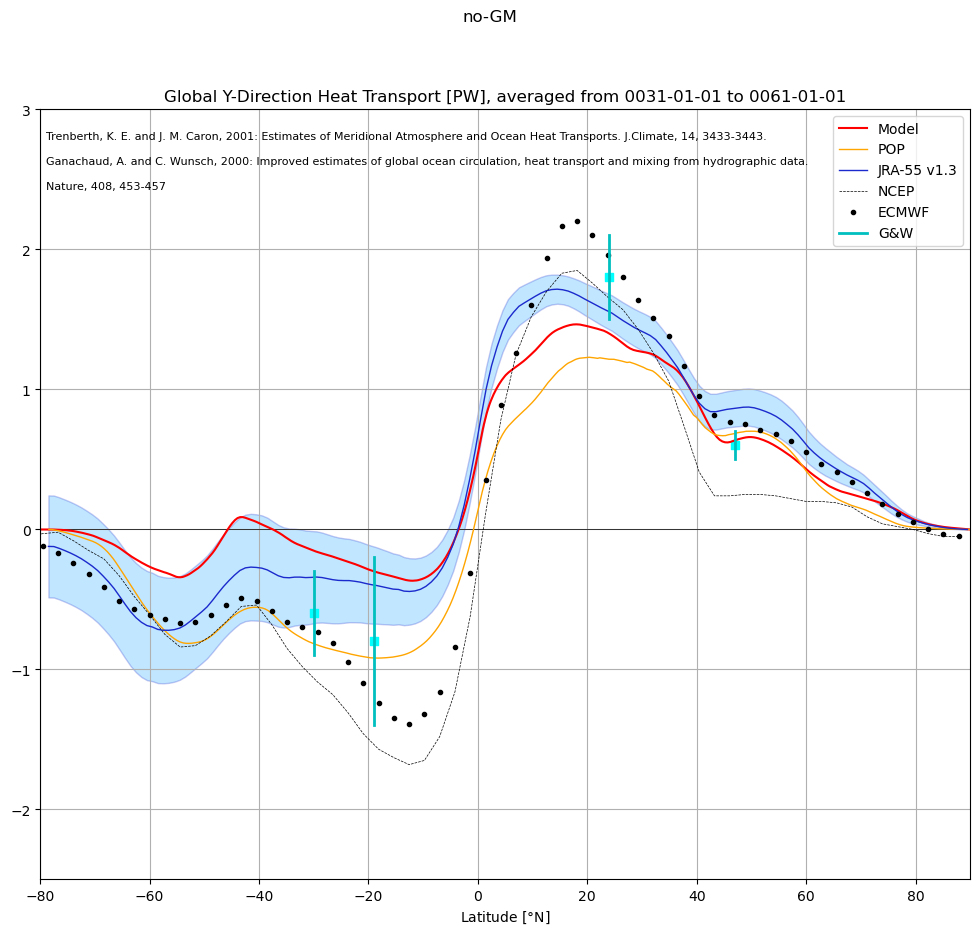

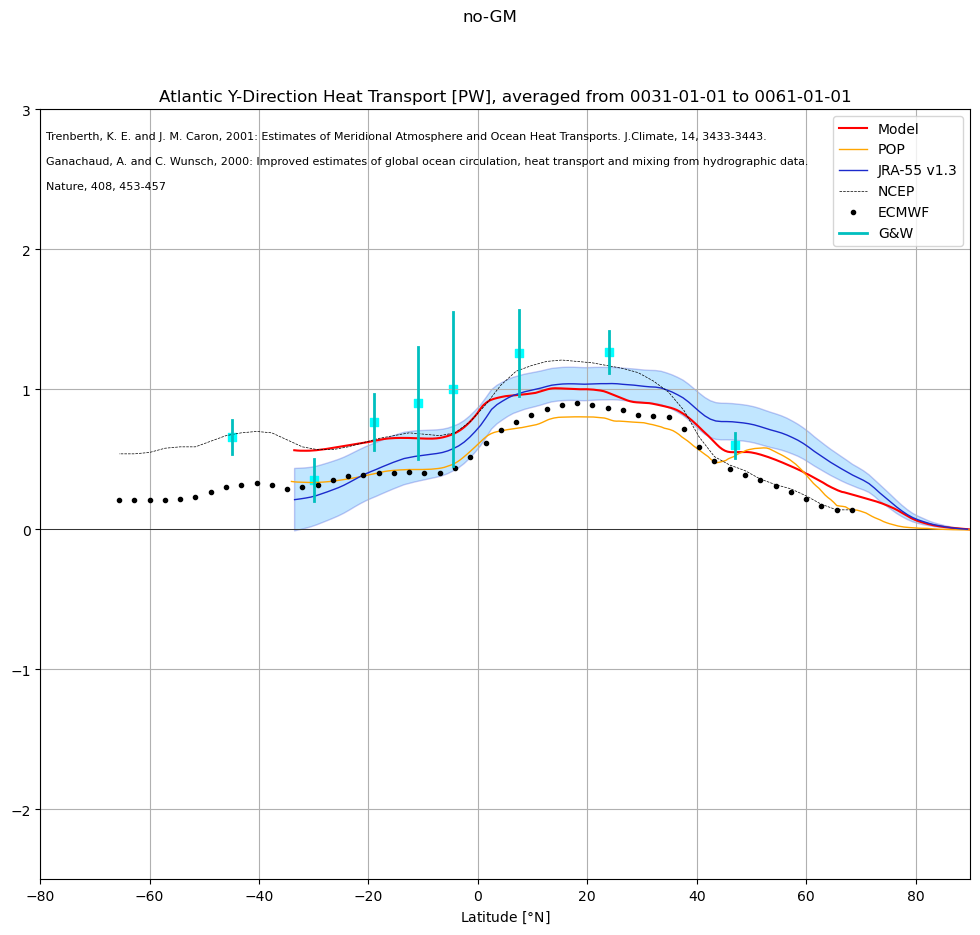

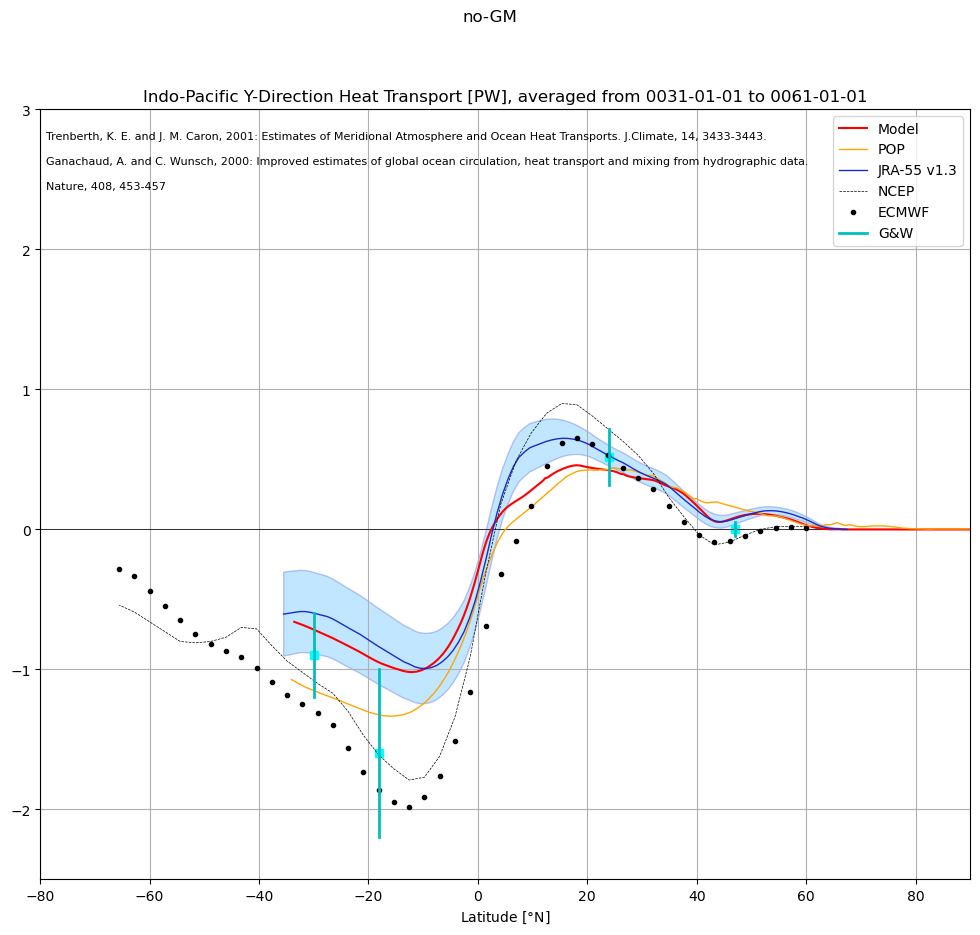

poleward_heat_transport.py was run successfully!


In [49]:
%matplotlib inline
plt_heat_transport_model_vs_obs(advective, diffusive, hbd, basin_code, grd, args)